In [1]:
pip install python_speech_features


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Project 2: HMM Phoneme Recognizer

## Notebook Roadmap
1. Configure environment and data paths (Colab or VS Code/local).
2. Load train, validation, and test utterance lists.
3. Align time-stamped phoneme labels to frame-level labels.
4. Estimate HMM parameters from the training split only.
5. Visualize transition behavior.
6. Implement inference (Filtering and Viterbi) and evaluate performance.

This structure is designed so each section produces outputs required by the next one.

In [1]:
import numpy as np
from python_speech_features import mfcc, delta
import os
from pathlib import Path

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    data_root = Path('/content/drive/Shareddrives/AI_RU/project2/data')
except ModuleNotFoundError:
    data_root = Path('data')

## Section 1: Data Paths and Split Loading

Goal: prepare consistent file paths and split lists for training, validation, and testing.

This section does two things:
1. Resolves dataset paths for both Colab and local VS Code execution.
2. Loads split files and matches feature files with label files.

What comes next: we convert time-based labels into frame-level state sequences.

In [4]:
feature_folder = data_root / '_out'
if not feature_folder.exists():
    feature_folder = data_root / 'out'

label_folder = data_root / 'cmu_us_slt_arctic' / 'lab'

txt_folder = data_root / 'txt'
if not txt_folder.exists():
    txt_folder = data_root / 'out'

In [5]:
with open(txt_folder / 'train.txt', 'r', encoding='utf-8') as f:
    train_filenames = [line.rstrip('\n') for line in f]
with open(txt_folder / 'test.txt', 'r', encoding='utf-8') as f:
    test_filenames = [line.rstrip('\n') for line in f]
with open(txt_folder / 'val.txt', 'r', encoding='utf-8') as f:
    val_filenames = [line.rstrip('\n') for line in f]

In [6]:
feature_files = [
    os.path.join(feature_folder, f)
    for f in os.listdir(feature_folder)
    if os.path.isfile(os.path.join(feature_folder, f)) and f.endswith('.npy')
]
feature_files = sorted(feature_files)

label_files = [
    os.path.join(label_folder, f)
    for f in os.listdir(label_folder)
    if os.path.isfile(os.path.join(label_folder, f)) and f.endswith('.lab')
]
label_files = sorted(label_files)

In [7]:
train_feature_files = []
train_label_files = []
test_feature_files = []
test_label_files = []

train_filename_set = set(train_filenames)
test_filename_set = set(test_filenames)

for feature_idx, feature_filename in enumerate(feature_files):
    feature_basename = Path(feature_filename).stem

    if feature_basename in train_filename_set:
        train_feature_files.append(feature_filename)
        train_label_files.append(label_files[feature_idx])

    if feature_basename in test_filename_set:
        test_feature_files.append(feature_filename)
        test_label_files.append(label_files[feature_idx])

## Section 2: Frame-Level Label Alignment

Goal: convert each utterance from time-stamped labels to one phoneme label per feature frame.

Why this matters:
1. HMM training needs aligned frame and label sequences.
2. Feature vectors and labels must have exactly the same length.

What comes next: supervised estimation of $\pi$, $A$, $\mu$, and $\Sigma$ from the training split.

In [8]:
def load_labels(label_file, arpabet_dic, n_frames, frame_step=0.01):
    label_array = np.genfromtxt(label_file, delimiter=" ", dtype=str)

    end_times = label_array[:, 0].astype(float)
    labels = label_array[:, 2]

    # frame times: 0.01, 0.02, ..., n_frames*frame_step
    frame_array = np.arange(1, n_frames + 1) * frame_step

    # for each end time, find how many frames are <= that boundary
    frame_ends = np.searchsorted(frame_array, end_times, side="left") + 1

    # convert cumulative frame counts into per-label counts
    counts = np.diff(np.r_[0, frame_ends])

    # repeat each label by its frame count
    states = np.repeat(labels, counts)

    # trim or pad to exactly n_frames
    states = states[:n_frames]

    if len(states) < n_frames:
        states = np.pad(states, (0, n_frames - len(states)), constant_values=labels[-1])

    states_num = np.array([arpabet_dic[p] for p in states], dtype=int)
    return states_num

## Section 3: Supervised HMM Parameter Estimation (Train Split)

Goal: estimate the four core HMM components using aligned training data only.

Estimated parameters:
1. $\pi$: initial state distribution.
2. $A$: transition matrix.
3. $\mu$: per-phoneme emission mean vector.
4. $\Sigma$: per-phoneme emission covariance matrix.

What comes next: compute each parameter block step by step, then move to inference.

In [9]:
ARPAbet_dic = {
    'aa': 0,
    'ae': 1,
    'ah': 2,
    'ao': 3,
    'aw': 4,
    'ay': 5,
    'b': 6,
    'ch': 7,
    'd': 8,
    'dh': 9,
    'eh': 10,
    'er': 11,
    'ey': 12,
    'f': 13,
    'g': 14,
    'hh': 15,
    'ih': 16,
    'iy': 17,
    'jh': 18,
    'k': 19,
    'l': 20,
    'm': 21,
    'n': 22,
    'ng': 23,
    'ow': 24,
    'oy': 25,
    'p': 26,
    'r': 27,
    's': 28,
    'sh': 29,
    't': 30,
    'th': 31,
    'uh': 32,
    'uw': 33,
    'v': 34,
    'w': 35,
    'y': 36,
    'z': 37,
    'zh': 38,
    'pau': 39,
    'ax': 40}
n_phonemes = len(ARPAbet_dic)

In [10]:
train_feature_list = []
for file in train_feature_files:
  feature_array = np.load(file)
  train_feature_list.append(feature_array)

test_feature_list = []
for file in test_feature_files:
  feature_array = np.load(file)
  test_feature_list.append(feature_array)

In [11]:
train_label_list = []
for file_idx, label_file in enumerate(train_label_files):
  feature_array = train_feature_list[file_idx]
  n_frames = feature_array.shape[0]
  label_array = load_labels(label_file, ARPAbet_dic, n_frames)
  train_label_list.append(label_array)

test_label_list = []
for file_idx, label_file in enumerate(test_label_files):
  feature_array = test_feature_list[file_idx]
  n_frames = feature_array.shape[0]
  label_array = load_labels(label_file, ARPAbet_dic, n_frames)
  test_label_list.append(label_array)

In [12]:
start_state_counts = {}
pau_id = ARPAbet_dic['pau']

for utterance in train_label_list:
    i = 0
    while i < len(utterance) and utterance[i] == pau_id:
        i += 1
    if i == len(utterance):
        continue
    first_phoneme = utterance[i]
    if first_phoneme in start_state_counts:
        start_state_counts[first_phoneme] += 1
    else:
        start_state_counts[first_phoneme] = 1

In [13]:
start_state_probs={}
for phoneme, count in start_state_counts.items():
    start_state_probs[phoneme] = count / len(train_label_list)

### 3.1 Initial Distribution $\pi$

We estimate $\pi$ from the first non-pause phoneme in each training utterance.

Why non-pause:
1. Many utterances begin with silence.
2. Using the first speech phoneme gives a more informative start prior.

What comes next: estimate transition probabilities between consecutive phoneme states.

In [14]:
initial_distribution = []
for phoneme in ARPAbet_dic.values():
  if phoneme in start_state_probs.keys():
    initial_distribution.append(start_state_probs[phoneme])
  else:
    initial_distribution.append(0)

### 3.2 Transition Matrix $A$

The transition matrix captures how phoneme states evolve over time:
$$a_{ij} = P(X_{t+1} = j | X_t = i)$$

Procedure:
1. Count all adjacent state pairs in training label sequences.
2. Normalize each row so it becomes a probability distribution.

What comes next: add smoothing for numerical stability and better generalization.

In [15]:
transition_matrix = np.zeros((n_phonemes, n_phonemes))
for utterance in train_label_list:
    for t in range(len(utterance) - 1):
        current_state = utterance[t]
        next_state = utterance[t + 1]
        transition_matrix[current_state, next_state] += 1

### 3.3 Smoothing and Normalization

Before final normalization, we add a small constant $\alpha$ to every transition count.

Why this helps:
1. Avoids zero-probability transitions.
2. Improves robustness for rare transitions in limited data.

What comes next: visualize the transition matrix and then estimate emissions.

In [16]:
alpha = 0.001
transition_matrix = transition_matrix + alpha
normalisation_values = np.sum(transition_matrix, axis=1, keepdims=True)
transition_matrix = transition_matrix / normalisation_values

In [17]:
transition_matrix_plot = transition_matrix.copy()
np.fill_diagonal(transition_matrix_plot, 0)

/home/ivanluq/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


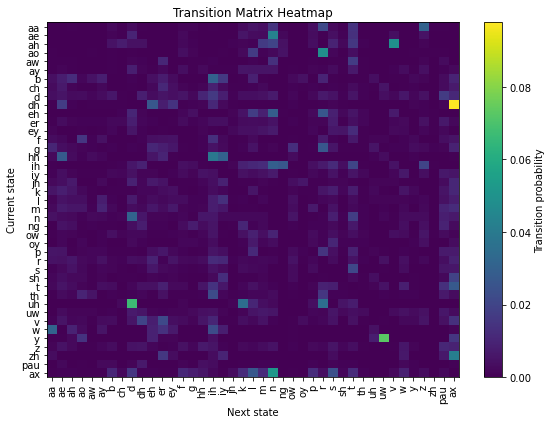

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# transition_matrix: shape (n_states, n_states)
# phoneme_names: list of state names in the same order as the matrix rows/cols

plt.figure(figsize=(8, 6))
plt.imshow(transition_matrix_plot, aspect="auto")
plt.colorbar(label="Transition probability")

plt.xticks(ticks=np.arange(n_phonemes), labels=ARPAbet_dic.keys(), rotation=90)
plt.yticks(ticks=np.arange(n_phonemes), labels=ARPAbet_dic.keys())

plt.xlabel("Next state")
plt.ylabel("Current state")
plt.title("Transition Matrix Heatmap")
plt.tight_layout()
plt.show()

### 3.4 Emission Parameters ($\mu$, $\Sigma$)

Goal: estimate one Gaussian emission model per phoneme state.

Procedure:
1. Gather all training frames assigned to each phoneme.
2. Compute mean vector $\mu_i$ and covariance matrix $\Sigma_i$.
3. Apply covariance regularization ($\lambda I$) for numerical stability.

What comes next: run inference algorithms on unseen sequences.

In [19]:
feature_mapping = [[] for _ in range(n_phonemes)]

for utterance_idx, utterance in enumerate(train_label_list):
    for label_idx, label in enumerate(utterance):
        row = train_feature_list[utterance_idx][label_idx, :]
        feature_mapping[label].append(row)

feature_mapping = [np.array(rows) for rows in feature_mapping]

In [20]:
emission_parameters = []
lam = 0.00001
feature_dim = train_feature_list[0].shape[1]
for phoneme in feature_mapping:
  if phoneme.shape[0] >= 2:
    mean = np.mean(phoneme, axis = 0)
    covariance = np.cov(phoneme, rowvar = False)
    covariance = covariance + np.eye(feature_dim) * lam
  elif phoneme.shape[0] == 1:
    mean = np.mean(phoneme, axis = 0)
    covariance = np.eye(feature_dim) * lam
  else:
    mean = np.zeros(feature_dim)
    covariance = np.eye(feature_dim) * lam

  emission_parameters.append([mean, covariance])

## Section 4: Inference Algorithms (Next)

We now move from parameter estimation to decoding.

Planned implementations:
1. Filtering (Forward algorithm) for frame-wise posterior state probabilities.
2. Viterbi decoding for the most likely phoneme path.

In [ ]:
def filtering():
    